# Dataset Analysis and Modification
This notebook focuses on analyzing and modifying the `hymenoptera` dataset. 

The key areas of analysis include:
- Identifying images with incorrect annotations
- Examining the distribution of different classes within the dataset
- Understanding the characteristics of the dataset, such as object positioning and background details

Based on these insights, we will then split and modify the original dataset accordingly.

In [1]:
# move to the directory where the data is stored
%cd ..
!ls

/remote/vast0/tran/workspace/ViT-pytorch
checkpoint  img      logs    notebook  README.md	 scripts  train.py
data	    LICENSE  models  output    requirements.txt  tools	  utils


## Incorrect Annotations

**Note:** All images with unclear or incorrect labels have been removed from training set.

In [2]:
# data path
data_path = './data/hymenoptera'

In [3]:
import os
from torchvision import datasets, transforms

# unclear data
train_unclear_path = os.path.join(data_path, 'train_unclear')
train_unclear_dataset = datasets.ImageFolder(root=train_unclear_path, transform=transforms.ToTensor())
print("Training data with unclear class: ", len(train_unclear_dataset))

Training data with unclear class:  5


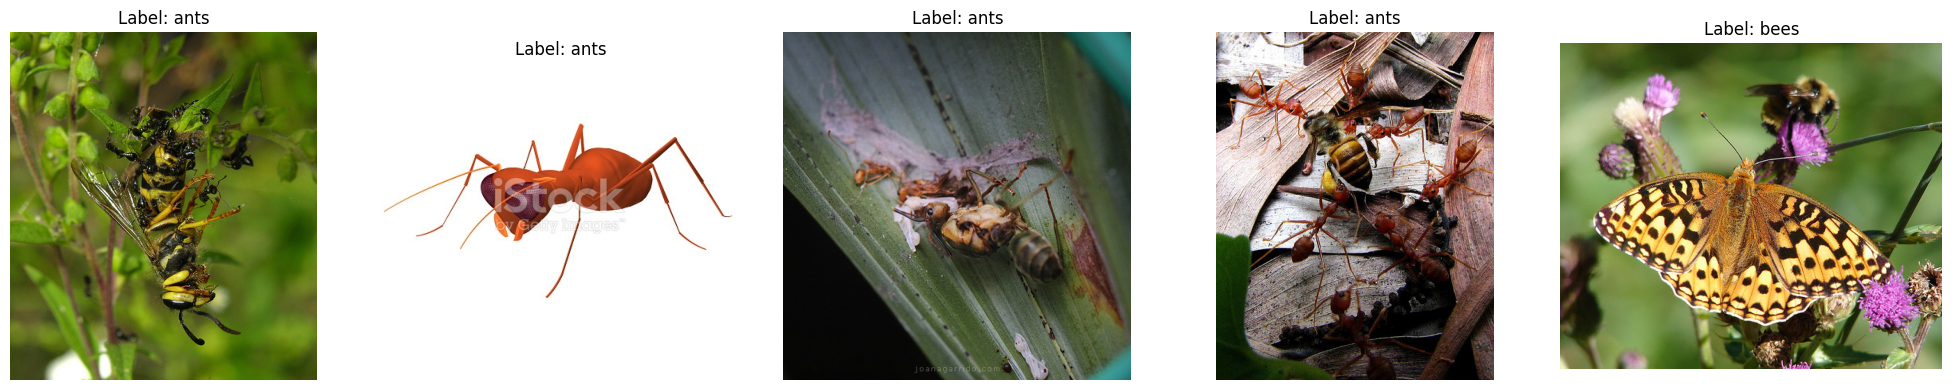

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes = axes.flatten()

for ax, (img, label) in zip(axes, train_unclear_dataset):
    ax.imshow(img.permute(1, 2, 0))  # (C, H, W) -> (H, W, C)
    ax.set_title(f'Label: {train_unclear_dataset.classes[label]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Dataset Overview

Note that training data has been cleaned and is ready for use.

In [6]:
# data transforms
from torchvision import datasets, transforms

# data path
train_data_path = os.path.join(data_path, 'train')
test_data_path = os.path.join(data_path, 'val') # there is no test data in the dataset

# clear data
trainset = datasets.ImageFolder(root=train_data_path, transform=transforms.ToTensor())
testset = datasets.ImageFolder(root=test_data_path, transform=transforms.ToTensor())
print("Trainset size: ", len(trainset))
print("Testset size: ", len(testset))

Trainset size:  239
Testset size:  153


**Note:** Set the test set aside. The training set is relatively small, which makes it challenging to create a validation set for tuning hyperparameters.

Here are some suitable approaches for creating a validation set:
- **Holdout Method:** Set aside approximately 20% of the training set for validation
- **Stratified K-Fold Cross-Validation:** Use 5-fold cross-validation to maximize the use of your data.

To make the most of our limited data, **Stratified K-Fold Cross-Validation** will be a more proper choice. Also, **stratified** ensures that each fold has the same proportion of classes as the entire dataset.

In [7]:
# split dataset
valset_size = int(0.2 * len(trainset))
trainset_size = len(trainset) - valset_size
testset_size = len(testset)

print("Trainset size: ", trainset_size)
print("Valset size: ", valset_size)
print("Testset size: ", testset_size)

Trainset size:  192
Valset size:  47
Testset size:  153


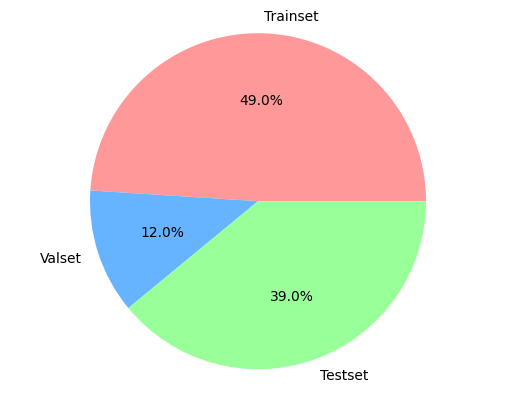

In [8]:
import matplotlib.pyplot as plt

labels = 'Trainset', 'Valset', 'Testset'
sizes = [trainset_size, valset_size, testset_size]

colors = ['#FF9999', '#66B3FF', '#99FF99']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
plt.axis('equal')
plt.show()

## Data Distribution

In [9]:
# view over classes
classes = trainset.classes
print(classes)

['ants', 'bees']


In [10]:
# images per class (trainset + valset)
class_count = {}
for i in range(len(classes)):
    class_count[classes[i]] = 0

for i in range(len(trainset)):
    class_ = classes[trainset[i][1]]
    class_count[class_] += 1

print(class_count)

{'ants': 119, 'bees': 120}


**Note:** The dataset consists of two classes: `ants` and `bees`. The data is balanced between these two classes (119 vs 120). Also, we assume that the distribution of the test set matches that of the training set, indicating that real-world data is also balanced.

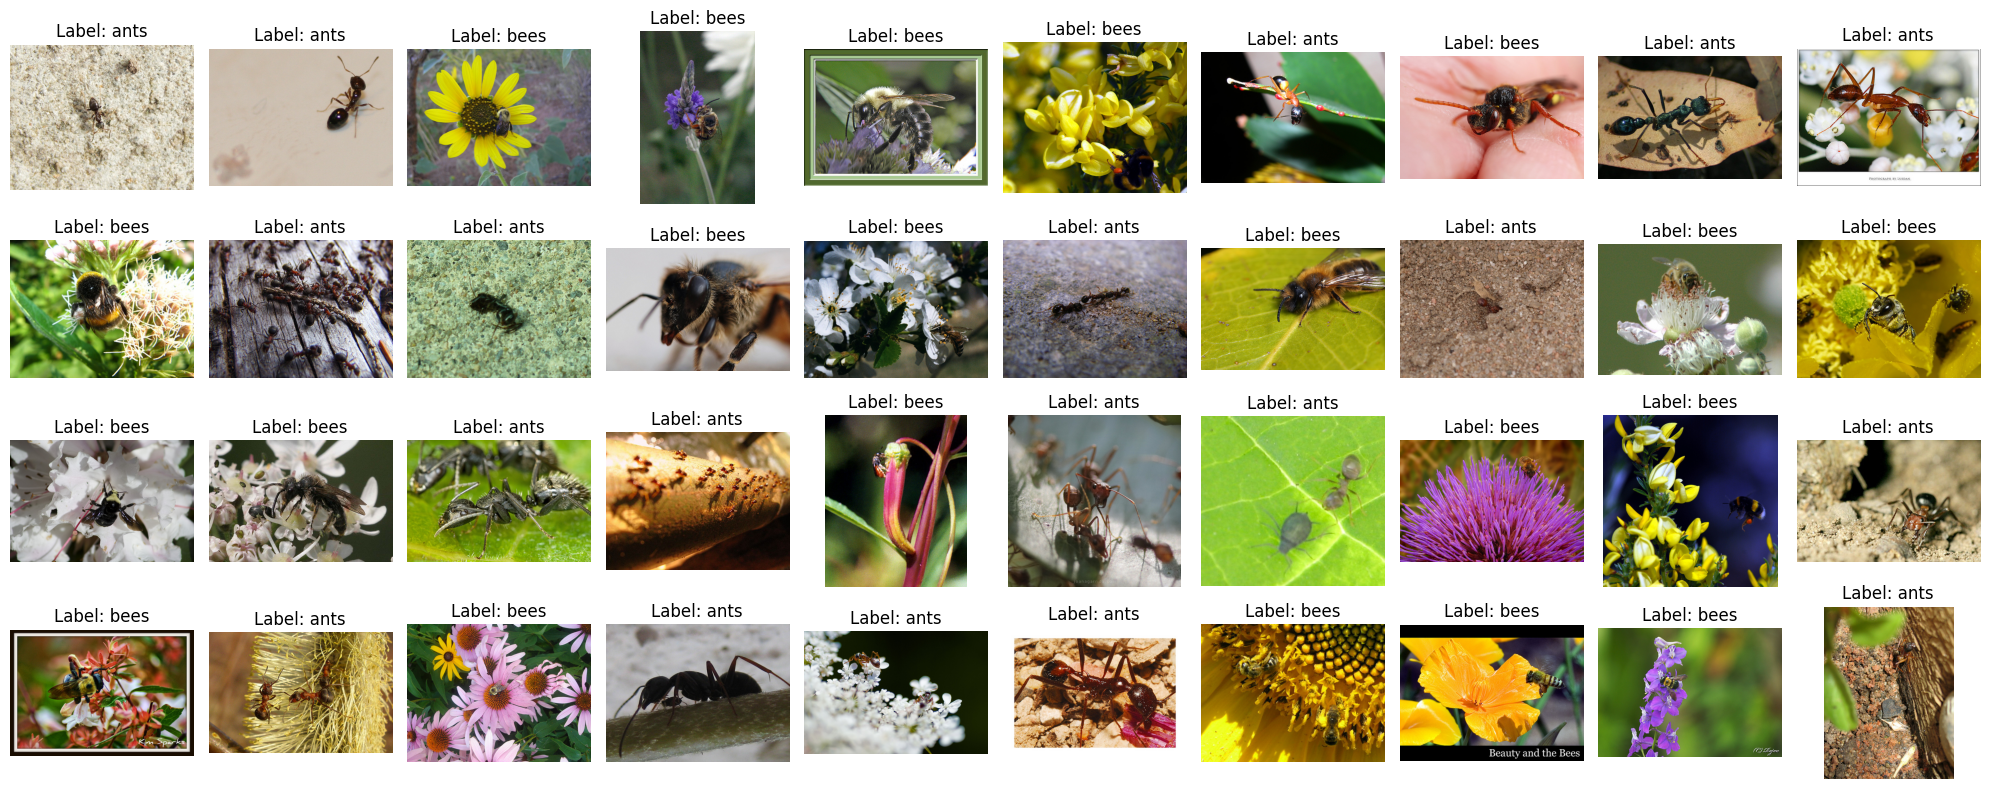

In [11]:
import random

num_samples = 40
random_indices = random.sample(range(len(trainset)), num_samples)
images = [trainset[idx][0] for idx in random_indices]
labels = [trainset[idx][1] for idx in random_indices]

# Set up the plot
fig, axes = plt.subplots(4, 10, figsize=(20, 8))
axes = axes.flatten()

# Plot the images
for ax, img, label in zip(axes, images, labels):
    ax.imshow(img.permute(1, 2, 0))  # (C, H, W) -> (H, W, C)
    ax.set_title(f'Label: {classes[label]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

**Note:**
- The images display a wide variety of shapes, aspect ratios and backgrouds.
- Most images are centered around objects, similar to ImageNet dataset.
- Since main objects are insects, so some images will have really small main object -> for ViT, using smaller patch size is better.
- Additionally, both ants and bees are part of the ImageNet classes and images are quite similar.
    - 309 -> bee
    ![Imagenet bee images](images/imagenet_309.png)
    - 310-> ant, emmet, pismire
    ![Imagenet ant images](images/imagenet_310.png)

In conclusion, using models **pretrained on Imagenet** with **small patch size** will be a good option.

## Conclusion

After analyzing the dataset, here is the action list:
- Use **Stratified K-Fold Cross-Validation** for validation.
- Use pretrained models on **Imagenet** with **small patch size**.